In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('bmh')
plt.rcParams['axes.facecolor'] = 'white'

In [2]:
y_true = np.load('../test-set-y_true.npy', allow_pickle=True)
y_pred_low = np.load('../test-set-y_pred_low.npy', allow_pickle=True)
y_pred_high = np.load('../test-set-y_pred_high.npy', allow_pickle=True)

In [3]:
mmsis = np.load('../all-mmsis-test.npy', allow_pickle=True)
days = np.load('../all-days-test.npy', allow_pickle=True)
timestamps_dict = np.load('../timestamps-dict.npy', allow_pickle=True)

In [4]:
mistake_mask = (
    (y_true[:, 0, 0] < y_pred_low[:, 0, 0]) |
    (y_true[:, 0, 0] > y_pred_high[:, 0, 0])
)

In [5]:
mistake_dict = {}
for ix, (mmsi, day) in enumerate( zip( mmsis, days ) ):

    if (mmsi, day) not in mistake_dict:
        mistake_dict[ (mmsi,day) ] = [ mistake_mask[ix] ]
    else:
        mistake_dict[ (mmsi,day) ].append( mistake_mask[ix] )

In [39]:
error_indices = {}

for (m,d), mask in mistake_dict.items():

    n = len(mask)
    indices = np.array( range(n) )
    error_ix = indices[mask]

    if len(error_ix) > 0:
        error_indices[m,d] = error_ix

In [46]:
df = pd.read_csv('../data/df-prepared.csv')
grouped = df.groupby(by=['MMSI', 'day'])
error_data = {}

for (mmsi, day), data in grouped:
    if (mmsi, day) in error_indices:
        indices = error_indices[(mmsi, day)]
        error_data[(mmsi, day)] = data.iloc[indices, :]

In [55]:
df['COG'].abs().mean()

np.float64(0.2666048122770432)

In [56]:
data.columns

Index(['SOG', 'COG', 'Cargo type', 'Width', 'Length', 'currentSpeed', 'gust',
       'swellHeight', 'waveHeight', 'windSpeed', 'COG_vec_x', 'COG_vec_y',
       'currentDirection_vec_x', 'currentDirection_vec_y',
       'swellDirection_vec_x', 'swellDirection_vec_y', 'waveDirection_vec_x',
       'waveDirection_vec_y', 'windDirection_vec_x', 'windDirection_vec_y',
       'COG-dif', 'delta_dif', 'MMSI', 'day'],
      dtype='str')

In [75]:
def box_plot_anomalies(error_data, df, col):
    values = []
    for (mmsi, day), data in error_data.items():
        values.extend( list(data[col].values) )

    fig, (ax1,ax2) = plt.subplots(ncols=2)
    ax1.boxplot(values)
    ax1.set_ylim((df[col].min(), df[col].max()))
    ax1.set_title(f'{col}-klaidos')

    ax2.boxplot(df[col])
    ax2.set_ylim((df[col].min(), df[col].max()))
    ax2.set_title(f'{col}-normalus')

    plt.show()

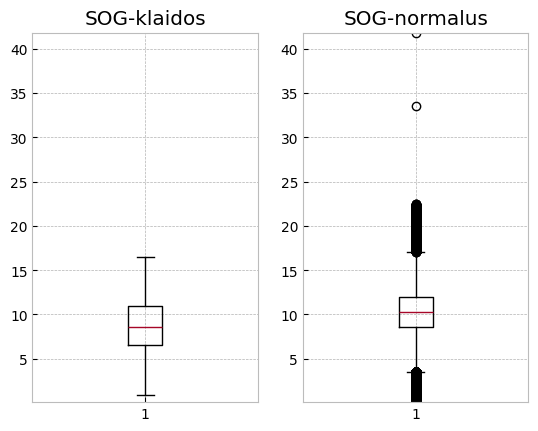

In [76]:
box_plot_anomalies(error_data, df, 'SOG')

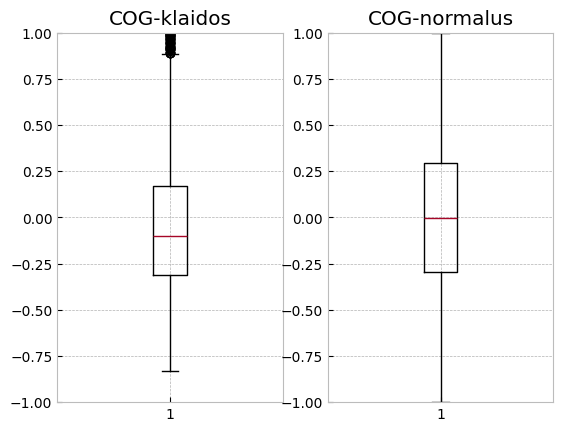

In [77]:
box_plot_anomalies(error_data, df, 'COG')

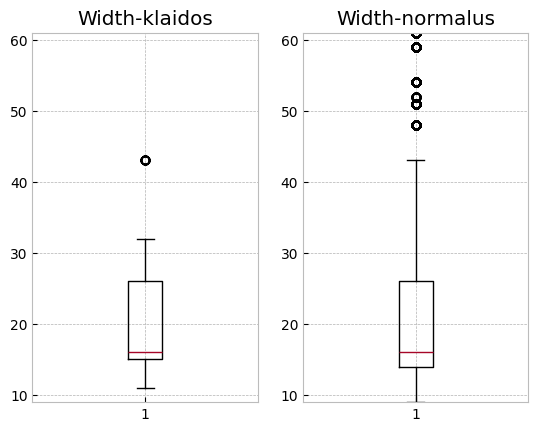

In [78]:
box_plot_anomalies(error_data, df, 'Width')

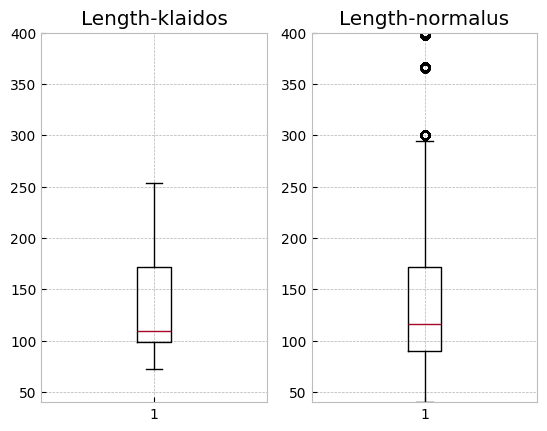

In [79]:
box_plot_anomalies(error_data, df, 'Length')

In [80]:
df

,SOG,COG,Cargo type,Width,Length,currentSpeed,gust,swellHeight,waveHeight,windSpeed,...,swellDirection_vec_x,swellDirection_vec_y,waveDirection_vec_x,waveDirection_vec_y,windDirection_vec_x,windDirection_vec_y,COG-dif,delta_dif,MMSI,day
0,8.70,-0.148889,No additional information,13.0,88.0,0.08,13.05,0.31,1.56,12.37,...,-0.999282,-0.037877,0.249540,0.968364,0.191820,-0.981430,0.002500,0.001528,205168000,2026-01-09
1,8.40,-0.145556,No additional information,13.0,88.0,0.08,13.05,0.31,1.56,12.37,...,-0.999282,-0.037877,0.249540,0.968364,0.191820,-0.981430,0.001667,-0.000833,205168000,2026-01-09
2,8.60,-0.141111,No additional information,13.0,88.0,0.08,13.05,0.31,1.56,12.37,...,-0.999282,-0.037877,0.249540,0.968364,0.191820,-0.981430,0.002222,-0.002500,205168000,2026-01-09
3,8.20,-0.148333,No additional information,13.0,88.0,0.08,13.05,0.31,1.56,12.37,...,-0.999282,-0.037877,0.249540,0.968364,0.191820,-0.981430,-0.003611,0.004583,205168000,2026-01-09
4,8.25,-0.153889,No additional information,13.0,88.0,0.08,13.05,0.31,1.56,12.37,...,-0.999282,-0.037877,0.249540,0.968364,0.191820,-0.981430,-0.002778,-0.001389,205168000,2026-01-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
522629,9.90,0.287778,No additional information,18.0,108.0,0.01,8.80,0.58,0.75,7.29,...,0.723305,0.690529,-0.981106,-0.193473,-0.102576,0.994725,-0.001111,-0.000556,667002439,2026-01-19
522630,9.80,0.285556,No additional information,18.0,108.0,0.01,8.80,0.58,0.75,7.29,...,0.723305,0.690529,-0.981106,-0.193473,-0.102576,0.994725,-0.001111,-0.000556,667002439,2026-01-19
522631,9.80,0.304444,No additional information,18.0,108.0,0.01,8.80,0.58,0.75,7.29,...,0.723305,0.690529,-0.981106,-0.193473,-0.102576,0.994725,0.009444,0.004722,667002439,2026-01-19
522632,9.80,0.282222,No additional information,18.0,108.0,0.01,8.80,0.58,0.75,7.29,...,0.723305,0.690529,-0.981106,-0.193473,-0.102576,0.994725,-0.011111,-0.005556,667002439,2026-01-19


In [85]:
df.columns

Index(['SOG', 'COG', 'Cargo type', 'Width', 'Length', 'currentSpeed', 'gust',
       'swellHeight', 'waveHeight', 'windSpeed', 'COG_vec_x', 'COG_vec_y',
       'currentDirection_vec_x', 'currentDirection_vec_y',
       'swellDirection_vec_x', 'swellDirection_vec_y', 'waveDirection_vec_x',
       'waveDirection_vec_y', 'windDirection_vec_x', 'windDirection_vec_y',
       'COG-dif', 'delta_dif', 'MMSI', 'day'],
      dtype='str')

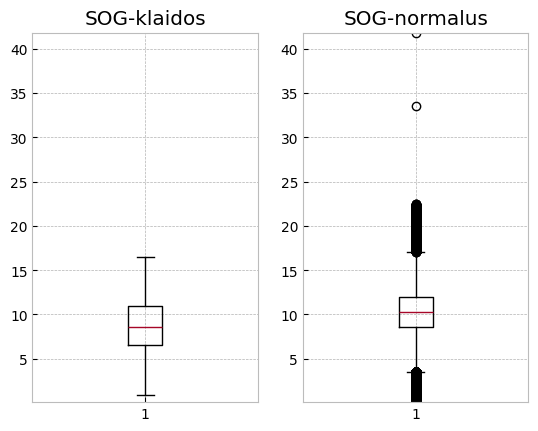

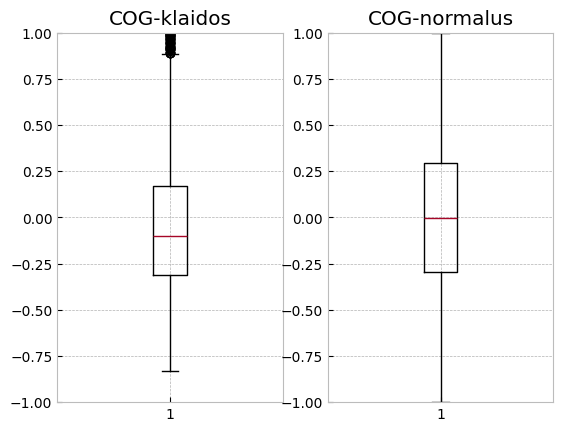

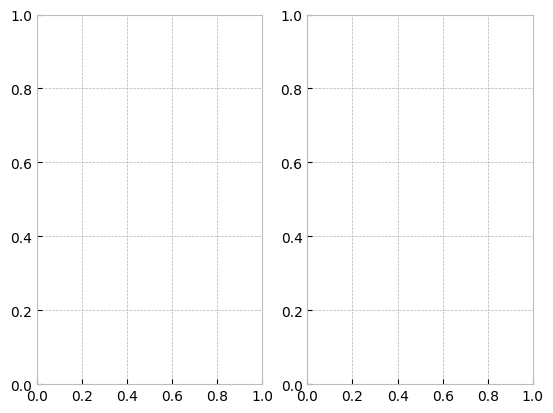

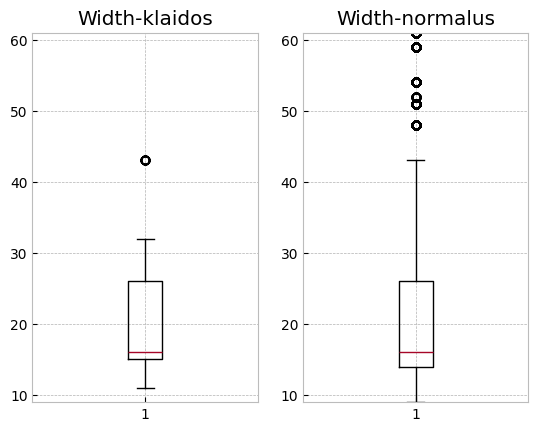

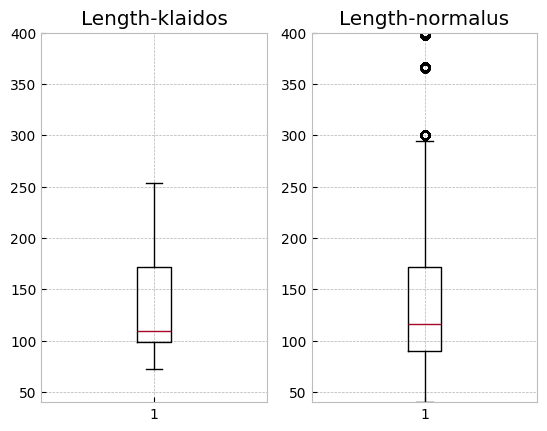

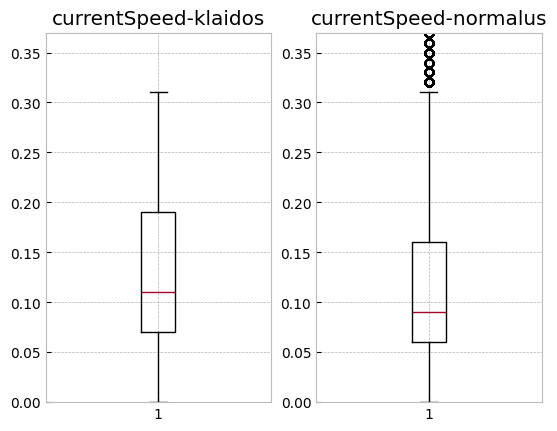

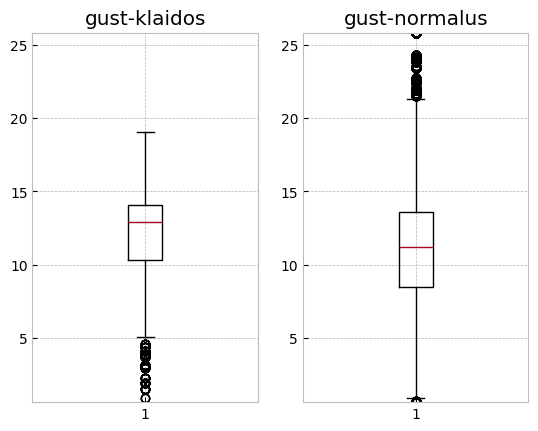

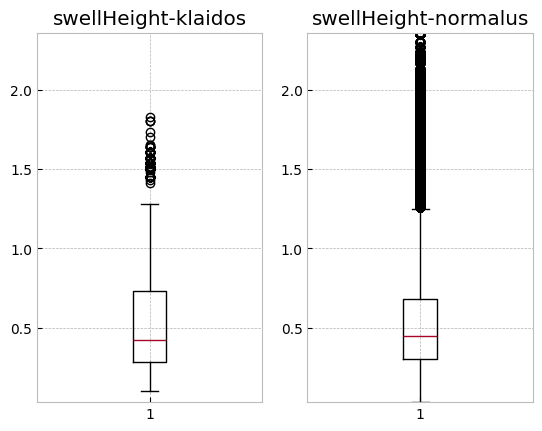

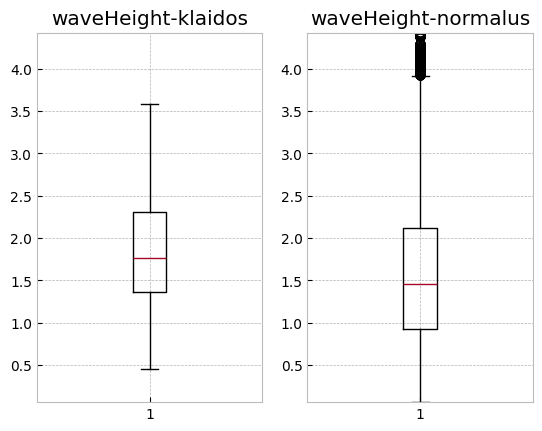

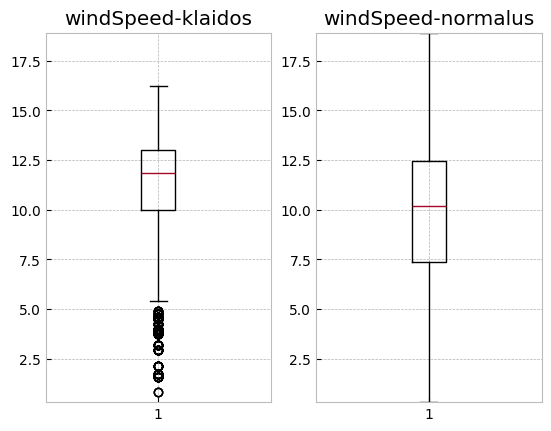

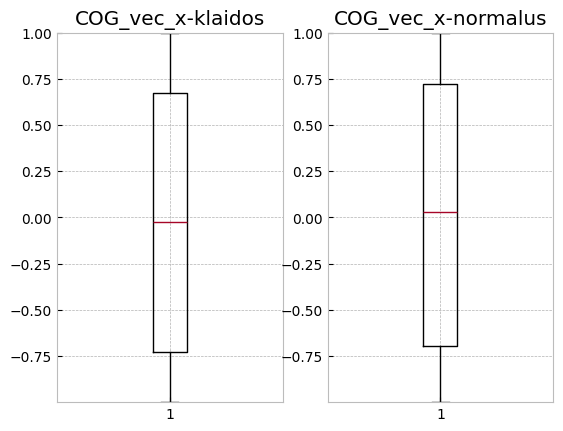

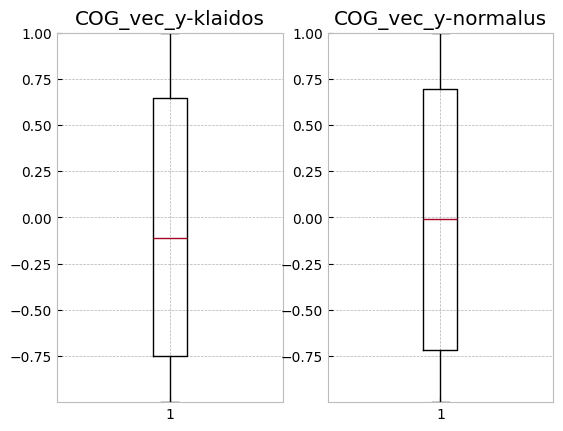

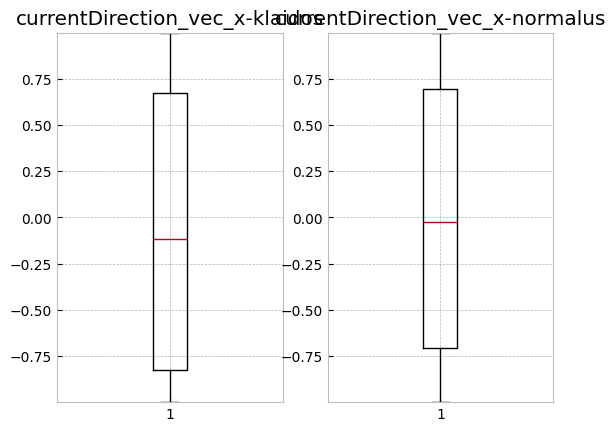

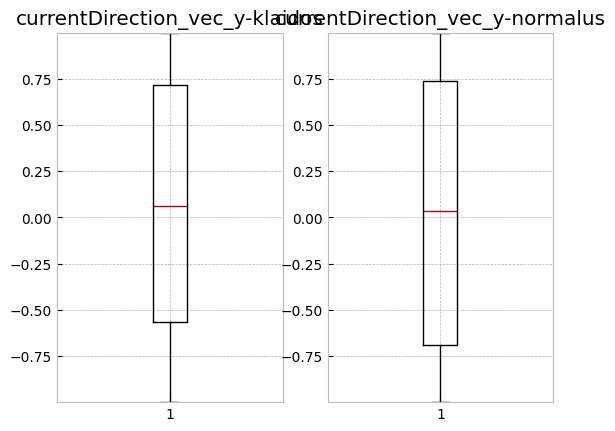

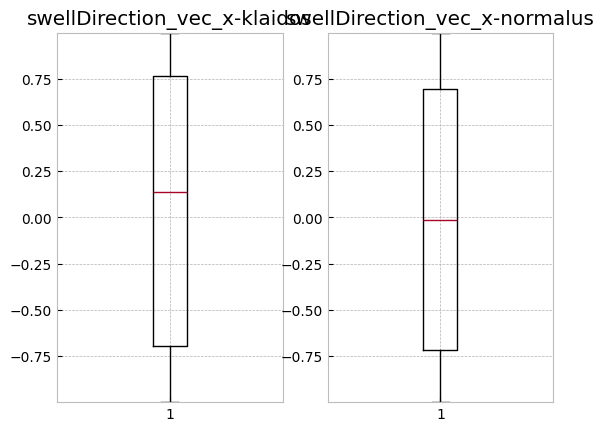

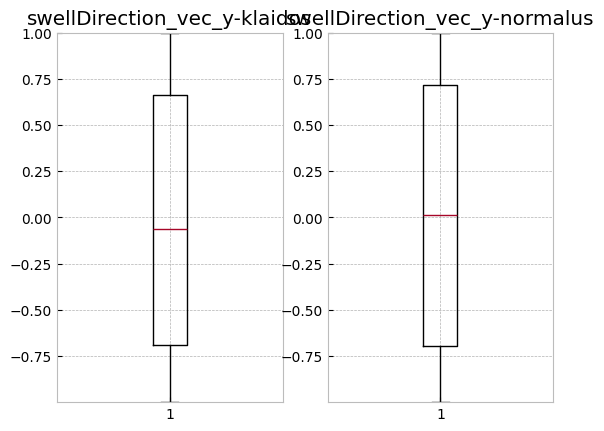

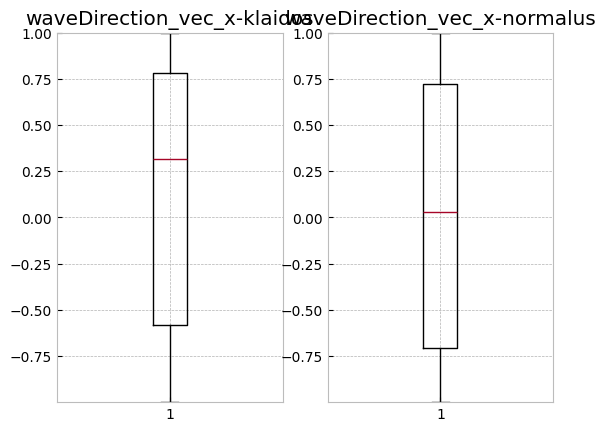

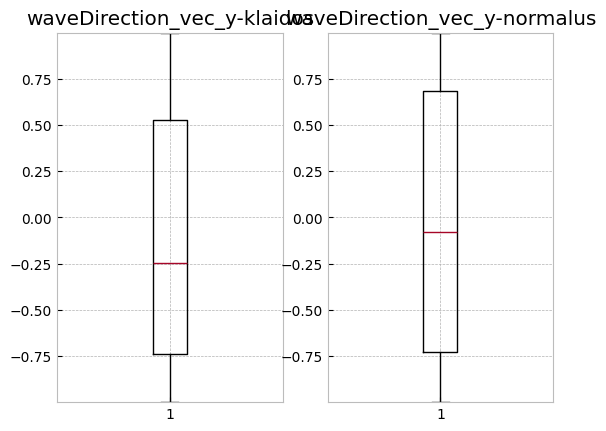

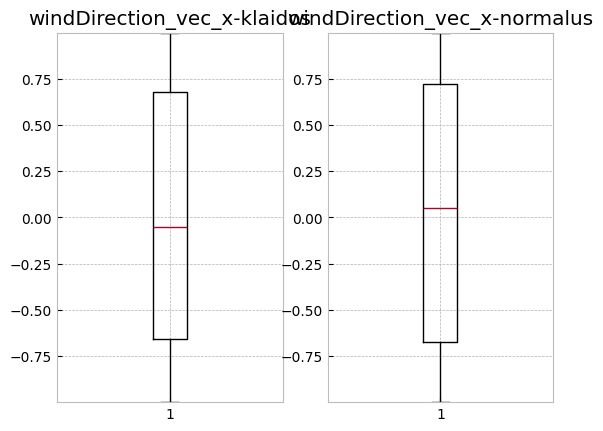

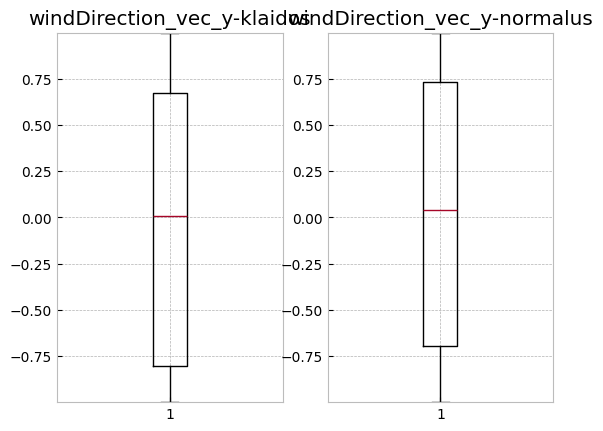

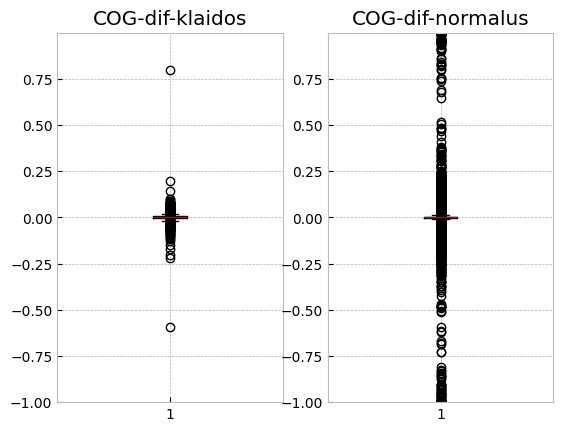

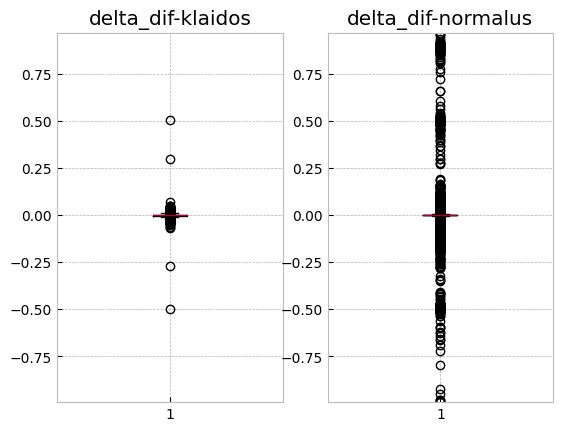

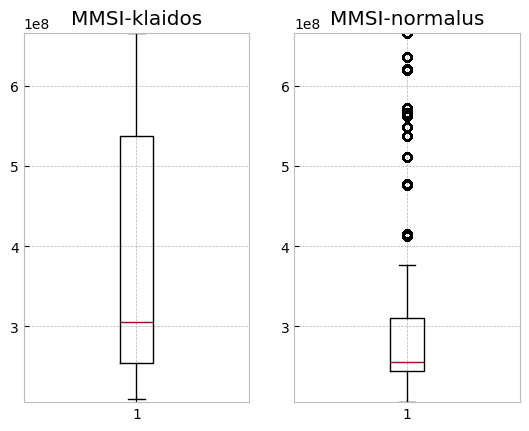

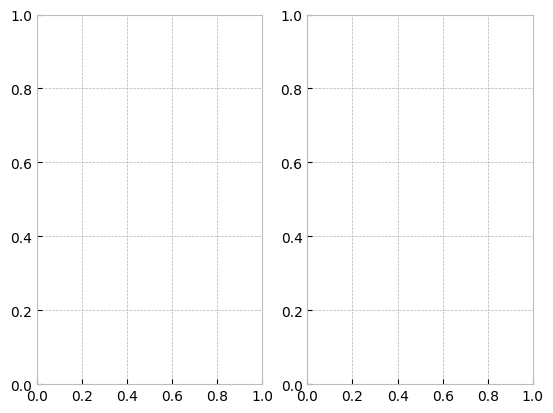

In [86]:
for col in df.columns:
    try:
        box_plot_anomalies(error_data, df, col)
    except:
        continue

In [6]:
mistake_counts = {}
mmsi_mistake_table = np.unique( mmsis[mistake_mask], return_counts=True )
days = np.unique( days[mistake_mask], return_counts=True )

for mmsi, mistake_count in zip(*mmsi_mistake_table):
    mistake_counts[mmsi] = mistake_count

In [7]:
mmsi_dict = {
    mmsi: mistakes
    for mmsi, mistakes in zip( *np.unique(mmsis, return_counts=True) )
}

In [8]:
import pandas as pd

In [9]:
mistake_df = {'mmsi': [], 'mistake_count': [], 'mistake_freq': [], 'total_seqs': []}

for mmsi, mistakes in mistake_counts.items():
    mistake_df['mmsi'].append(mmsi)
    mistake_df['mistake_count'].append(mistakes)
    mistake_df['total_seqs'].append(mmsi_dict[mmsi])
    mistake_df['mistake_freq'].append(mistakes / mmsi_dict[mmsi])

mistake_df = pd.DataFrame(mistake_df)

In [10]:
more_than_yipeng3 = mistake_df[ 1 - mistake_df['mistake_freq'] < 0.9 ]
more_than_yipeng3

,mmsi,mistake_count,mistake_freq,total_seqs
1,209276000,22,0.305556,72
2,209621000,36,0.226415,159
4,209708000,30,0.120968,248
6,209732000,74,0.368159,201
8,210195000,10,0.126582,79
...,...,...,...,...
156,636023222,13,0.100775,129
157,636023244,354,0.259721,1363
158,636025461,11,0.122222,90
159,636092951,23,0.119171,193


In [11]:
df = pd.read_csv('../data/df-prepared.csv')

In [12]:
mmsi_mask = df['MMSI'].apply( lambda x: x in more_than_yipeng3['mmsi'].unique() )

In [12]:
df[mmsi_mask]['Cargo type'].unique()

<StringArray>
['No additional information',                'Category X',
                'Category Y',                'Category Z',
               'Category OS',   'Reserved for future use']
Length: 6, dtype: str

In [13]:
df[mmsi_mask]['Length'].unique()

array([ 88., 153.,  82., 168.,  90., 170., 100., 101., 121.,  99.,  98.,
        85., 159., 151., 184.,  89., 152., 118., 190.,  87.,  72.,  55.,
       200.,  60., 172., 148., 155.,  95., 131., 134., 111.,  83., 103.,
       120., 137., 106., 179.,  86., 108., 195., 123., 110., 130., 145.,
       143., 115., 154., 133., 112., 109., 150., 205., 128., 114., 126.,
       204., 141., 136., 116., 117., 158., 149., 187., 229., 169., 186.,
        80.,  91., 242.,  92., 122.,  81., 107.,  93., 140., 166., 142.,
       138., 132., 180.,  79., 227., 225., 196., 211., 399., 188., 199.,
       183., 253., 398., 178., 139., 207., 235., 161., 198., 208.])

In [14]:
df[mmsi_mask]['Width'].unique()

array([12., 24., 26., 16., 27., 14., 11., 17., 13., 19., 22., 25., 23.,
       20., 15., 32.,  9., 36., 10., 21., 30., 18., 28., 33., 61., 43.,
       51.])

## Laivų specifika (remiantis MarineTraffic ir VesselFinder)

219136000 - 200 x 36 m krovininis A pavojingumo klasės laivas, gabenantis labai pavojingą krovinį.

235102851 - 177 / 28 m krovininis laivas, gabenantis nepavojingą krovinį

244130689 - 196 / 26 m krovininis Ro-Ro A pavojingumo klasės laivas, gabenantis pavojingą krovinį.

244130873 - 137 / 22 m krovininis laivas, gabenantis nepavojingą krovinį

246191000 - 137 / 22 m krovininis A pavojingumo klasės laivas, gabenantis labai pavojingą krovinį.

255806507 - 300 / 48 m krovininis D pavojingumo klasės laivas.

257516000 - 213 / 32 m krovininis laivas

314837000 - 134 / 19 m krovininis laivas

341578001 - 89 / 13 m krovininis laivas

352586000 - 229 / 32 m

354711000 - 196 / 33 m

636016848 - 199 / 32 m

636017277 - 200 / 32 m

### Klaidų analizės planas:

1. Laivų specifikos (ilgis, plotis) prieš
2. Greičio ir pozicijos reikšmės
3. Požyimių grafikai
4. 